## Notebook Overview
- Purpose: Process Eurovision voting datasets and produce validation/analysis outputs.
- Inputs: CSV files from the local `Input` directory.
- Outputs: Derived tables/files in the local `Output` directory.
- Notes: Legacy logic is intentionally preserved; compatibility shims keep behavior stable on modern Python/Pandas.


# TOP 10 CLUSTER PLOT
This jupyter notebook generated two groups of plots:
1. Top 10 cluster plots using average/binary score and kendall score of top 10 jury ranks across all jurors in a single country to identify intra-country juror collusion
2. Top X cluster plots using only the average of top X jury ranks across all juror in a single country to identify intra-country juror collusion

## Stage 0. Setting up environment
- Adjusting layout
- Import libraries 

In [1]:
from IPython.core.display import display, HTML
display(HTML(
    '<style>'
        '#notebook { padding-top:0px !important; } ' 
        '.container { width:100% !important; } '
        '.end_space { min-height:0px !important; } '
    '</style>'
))

C:\Users\peda1\AppData\Local\Temp\ipykernel_1172\233690474.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [2]:
# Only useful in Jupyter to increase the number of visible rows/columns
import pandas as pd

# Pandas 2.x compatibility shim for legacy DataFrame.append usage
if not hasattr(pd.DataFrame, "append"):
    def _df_append(self, other, ignore_index=False, verify_integrity=False, sort=False):
        if isinstance(other, pd.DataFrame):
            to_concat = [self, other]
        else:
            to_concat = [self, pd.DataFrame([other])]
        return pd.concat(to_concat, ignore_index=ignore_index, verify_integrity=verify_integrity, sort=sort)
    pd.DataFrame.append = _df_append

pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 500)
pd.set_option("display.width", 1000)

In [3]:
import os
import shutil
import stat
import hashlib
import pandas as pd
from sqlalchemy import create_engine
import math
import numpy as np
try:
    import kendall_w as kw
except ImportError:
    class kw:
        @staticmethod
        def compute_w(rankings):
            import numpy as np
            arr = np.asarray(rankings, dtype=float)
            if arr.ndim != 2:
                raise ValueError("rankings must be a 2D array-like structure")
            m, n = arr.shape
            if m < 2 or n < 2:
                return 0.0
            col_sums = np.sum(arr, axis=0)
            mean_sum = np.mean(col_sums)
            s = np.sum((col_sums - mean_sum) ** 2)
            denom = (m ** 2) * (n ** 3 - n)
            if denom == 0:
                return 0.0
            return (12 * s) / denom
from tqdm import tqdm
import scipy.stats
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'kendall_w'

## Stage 1. Outlining paths and data structures
- Outlining paths 
- Reading key dataframes

In [ ]:
########################
### STATIC VARIABLES ###
########################

SOURCE_DIRECTORY = "."
SQL_DB_DIRECTORY = ""
SOURCE_CSV_DIRECTORY = "Input"
GRAPH_OUTPUT_DIRECTORY = "Graph_Export"
VALIDATION_SCRIPT_XLSX_DIRECTORY = "Validation_Export"

DICT_ISO = {
    "Albania": "AL",
    "Andorra": "AD",
    "Armenia": "AM",
    "Australia": "AU",
    "Austria": "AT",
    "Azerbaijan": "AZ",
    "Belarus": "BY",
    "Belgium": "BE",
    "Bosnia & Herzegovina": "BA",
    "Bulgaria": "BG",
    "Croatia": "HR",
    "Cyprus": "CY",
    "Czechia": "CZ",
    "Denmark": "DK",
    "Estonia": "EE",
    "Finland": "FI",
    "France": "FR",
    "Georgia": "GE",
    "Germany": "DE",
    "Greece": "GR",
    "Hungary": "HU",
    "Iceland": "IS",
    "Ireland": "IE",
    "Israel": "IL",
    "Italy": "IT",
    "Latvia": "LV",
    "Lithuania": "LT",
    "Luxembourg": "LU",
    "Malta": "MT",
    "Moldova": "MD",
    "Monaco": "MC",
    "Montenegro": "ME",
    "Morocco": "MA",
    "Netherlands": "NL",
    "North Macedonia": "MK",
    "Norway": "NO",
    "Poland": "PL",
    "Portugal": "PT",
    "Romania": "RO",
    "Russia": "RU",
    "San Marino": "SM",
    "Serbia": "RS",
    "Slovakia": "SK",
    "Slovenia": "SI",
    "Spain": "ES",
    "Sweden": "SE",
    "Switzerland": "CH",
    "Turkey": "TR",
    "Ukraine": "UA",
    "United Kingdom": "GB",
    "Rest of World": "RoW",
}


##############
# JURORS CSV #
##############

SF1_JURORS_CSV_FILE_PATH = os.path.join(
    SOURCE_CSV_DIRECTORY, "ESC2025-jurorresults_SF1-Cleaned.csv"
)

SF2_JURORS_CSV_FILE_PATH = os.path.join(
    SOURCE_CSV_DIRECTORY, ""
)

GF_JURORS_CSV_FILE_PATH = os.path.join(
    SOURCE_CSV_DIRECTORY, ""
)


# Mapping function
def rank_to_exp_score(rank):
    if rank == 1:
        return 12
    
    elif rank == 2:
        return 9.92351
    
    elif rank == 3:
        return 8.20634
    
    elif rank == 4:
        return 6.78631
    
    elif rank == 5:
        return 5.612
    
    elif rank == 6:
        return 4.64089
    
    elif rank == 7:
        return 3.83783
    
    elif rank == 8:
        return 3.17373
    
    elif rank == 9:
        return 2.62454
    
    elif rank == 10:
        return 2.17039
    
    elif rank == 11:
        return 1.79482
    
    elif rank == 12:
        return 1.48425
    
    elif rank == 13:
        return 1.22741
    
    elif rank == 14:
        return 1.01502
    
    elif rank == 15:
        return 0.83938
    
    elif rank == 16:
        return 0.69413
    
    elif rank == 17:
        return 0.57402
    
    elif rank == 18:
        return 0.47469
    
    elif rank == 19:
        return 0.39255
    
    elif rank == 20:
        return 0.32462
    
    elif rank == 21:
        return 0.26845
    
    elif rank == 22:
        return 0.222
    
    elif rank == 23:
        return 0.18358
    
    elif rank == 24:
        return 0.15181
    
    elif rank == 25:
        return 0.12554
    
    elif rank == 26:
        return 0.10382
    
    elif rank == 0:
        return 0
    
    else:
        raise RankError(f'Invalid Rank Value Provided for Exp. Scoring Mapping: {rank}')

# Store all provided CSVs to dataframes
try:
    sf1_jurors_df = pd.read_csv(SF1_JURORS_CSV_FILE_PATH, sep=";")
except FileNotFoundError:
    print("\n### Missing SF1 Jurors CSV file, skipping...")
try:
    sf2_jurors_df = pd.read_csv(SF2_JURORS_CSV_FILE_PATH, sep=";")
except:
    print("\n### Missing SF2 Jurors CSV file, skipping...")
try:
    gf_jurors_df = pd.read_csv(GF_JURORS_CSV_FILE_PATH, sep=";")
except FileNotFoundError:
    print("\n### Missing GF Jurors CSV file, skipping...")


### Missing SF2 Jurors CSV file, skipping...

### Missing GF Jurors CSV file, skipping...


In [4]:
# Picking df to analyze
########################################
selected_df_name = "sf1_jurors_df"
# selected_df_name = 'sf2_jurors_df'
# selected_df_name = 'gf_jurors_df'
########################################
selected_df = eval(selected_df_name)

print(
    f"Top-10 Cluster Analysis running for dataframe =>***{selected_df_name}***<=\n"
)

top10_cluster_scores_dict = {}
kendall_w_dict = {}
binary_top10_dict = {}
common_to_all_top10_dict = {}

NameError: name 'sf1_jurors_df' is not defined

In [14]:
# Add full countries names
inverted_DICT_ISO = {v: k for k, v in DICT_ISO.items()}

# Add the new column "ownICO_FULL" based on the mapping
countries_df = selected_df.assign(
    ownICO_FULL=selected_df["ownICO"].map(inverted_DICT_ISO)
)

# Move the new column to the first position
countries_df.insert(
    1, "ownICO_FULL", countries_df.pop("ownICO_FULL")
)

# Add the new column "votedICO_FULL" based on the mapping
countries_df = countries_df.assign(
    votedICO_FULL=selected_df["votedICO"].map(inverted_DICT_ISO)
)

# Move the new column to the first position
countries_df.insert(
    5, "votedICO_FULL", countries_df.pop("votedICO_FULL")
)

# Adding event name as suffix to country names
if selected_df_name[2:3].upper() == '_':
    suffix = f" - {selected_df_name[0:2].upper()}"
else:
    suffix = f" - {selected_df_name[0:3].upper()}"

countries_df['ownICO_FULL'] = countries_df['ownICO_FULL'].astype(str) + suffix
countries_df['votedICO_FULL'] = countries_df['votedICO_FULL'].astype(str) + suffix

selected_df = countries_df

# Add final rankings from validation script
#OBSOLETE
#selected_df = selected_df.merge(ranks_from_validation_df[['votedICO_FULL', 'Final_Rank']], on='votedICO_FULL', how='left')

selected_df.to_excel(f'parsed_{selected_df_name}.xlsx')

In [15]:
### ONLY RUN AFTER SF2 ###
'''
# SF2-specific parsing for aggregated values 

sf2_df_name = 'sf2_jurors_df'

sf2_df = eval(sf2_df_name)

# Add full countries names
inverted_DICT_ISO = {v: k for k, v in DICT_ISO.items()}

# Add the new column "ownICO_FULL" based on the mapping
countries_sf2_df = sf2_df.assign(
    ownICO_FULL=sf2_df["ownICO"].map(inverted_DICT_ISO)
)

# Move the new column to the first position
countries_sf2_df.insert(
    1, "ownICO_FULL", countries_sf2_df.pop("ownICO_FULL")
)

# Add the new column "votedICO_FULL" based on the mapping
countries_sf2_df = countries_sf2_df.assign(
    votedICO_FULL=sf2_df["votedICO"].map(inverted_DICT_ISO)
)

# Move the new column to the first position
countries_sf2_df.insert(
    5, "votedICO_FULL", countries_sf2_df.pop("votedICO_FULL")
)

# Adding event name as suffix to country names
if sf2_df_name[2:3].upper() == '_':
    suffix = f" - {sf2_df_name[0:2].upper()}"
else:
    suffix = f" - {sf2_df_name[0:3].upper()}"

countries_sf2_df['ownICO_FULL'] = countries_sf2_df['ownICO_FULL'].astype(str) + suffix
countries_sf2_df['votedICO_FULL'] = countries_sf2_df['votedICO_FULL'].astype(str) + suffix

sf2_df = countries_sf2_df

# Add final rankings from validation script
#OBSOLETE
#sf2_df = sf2_df.merge(ranks_from_validation_df[['votedICO_FULL', 'Final_Rank']], on='votedICO_FULL', how='left')

sf2_df.to_excel(f'parsed_{sf2_df_name}.xlsx')

selected_df = selected_df.append(sf2_df, ignore_index=True)
'''

'\n# SF2-specific parsing for aggregated values \n\nsf2_df_name = \'sf2_jurors_df\'\n\nsf2_df = eval(sf2_df_name)\n\n# Add full countries names\ninverted_DICT_ISO = {v: k for k, v in DICT_ISO.items()}\n\n# Add the new column "ownICO_FULL" based on the mapping\ncountries_sf2_df = sf2_df.assign(\n    ownICO_FULL=sf2_df["ownICO"].map(inverted_DICT_ISO)\n)\n\n# Move the new column to the first position\ncountries_sf2_df.insert(\n    1, "ownICO_FULL", countries_sf2_df.pop("ownICO_FULL")\n)\n\n# Add the new column "votedICO_FULL" based on the mapping\ncountries_sf2_df = countries_sf2_df.assign(\n    votedICO_FULL=sf2_df["votedICO"].map(inverted_DICT_ISO)\n)\n\n# Move the new column to the first position\ncountries_sf2_df.insert(\n    5, "votedICO_FULL", countries_sf2_df.pop("votedICO_FULL")\n)\n\n# Adding event name as suffix to country names\nif sf2_df_name[2:3].upper() == \'_\':\n    suffix = f" - {sf2_df_name[0:2].upper()}"\nelse:\n    suffix = f" - {sf2_df_name[0:3].upper()}"\n\ncountrie

In [16]:
# QC: Counting distinct values for each field
print(f"Checking distinct values in {selected_df_name}:\n")

unique_EBU_ID_values = selected_df['EBU_ID'].nunique()
print(f"Number of unique EBU_ID values: {unique_EBU_ID_values}\n")
# print("Unique EBU_ID values:", selected_df['EBU_ID'].unique())

unique_ownICO_values = selected_df['ownICO'].nunique()
print(f"Number of unique ownICO values: {unique_ownICO_values}\n")

unique_ownICO_FULL_values = selected_df['ownICO_FULL'].nunique()
print(f"Number of unique ownICO_FULL values: {unique_ownICO_FULL_values}\n")

unique_function_values = selected_df['function'].nunique()
print(f"Number of unique function values: {unique_function_values}\n")

unique_name_values = selected_df['name'].nunique()
print(f"Number of unique name values: {unique_name_values}\n")

unique_votedICO_values = selected_df['votedICO'].nunique()
print(f"Number of unique votedICO values: {unique_votedICO_values}\n")

unique_votedICO_FULL_values = selected_df['votedICO_FULL'].nunique()
print(f"Number of unique votedICO_FULL values: {unique_votedICO_FULL_values}\n")

unique_rank_values = selected_df['rank'].nunique()
print(f"Number of unique rank values: {unique_rank_values}\n")

# TODO: Implement counts check

Checking distinct values in sf1_jurors_df:

Number of unique EBU_ID values: 90

Number of unique ownICO values: 18

Number of unique ownICO_FULL values: 18

Number of unique function values: 5

Number of unique name values: 90

Number of unique votedICO values: 15

Number of unique votedICO_FULL values: 15

Number of unique rank values: 16



In [17]:
for country in tqdm(selected_df['ownICO_FULL'].unique()):
    print(country)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<?, ?it/s]

Iceland - SF1
Italy - SF1
Sweden - SF1
Norway - SF1
Switzerland - SF1
Belgium - SF1
Estonia - SF1
Spain - SF1
Slovenia - SF1
Cyprus - SF1
Portugal - SF1
San Marino - SF1
Netherlands - SF1
Poland - SF1
Ukraine - SF1
Albania - SF1
Croatia - SF1
Azerbaijan - SF1


 11%|███████████████████                                                                                                                                                         | 2/18 [00:00<00:01, 15.39it/s]

Country "Sweden - SF1" is found in all 5 jurors of Iceland - SF1
Country "Netherlands - SF1" is found in all 5 jurors of Iceland - SF1
Country "Norway - SF1" is found in all 5 jurors of Iceland - SF1
Country "Belgium - SF1" is found in all 5 jurors of Iceland - SF1
Country "Ukraine - SF1" is found in all 5 jurors of Italy - SF1
Country "Estonia - SF1" is found in all 5 jurors of Italy - SF1
Country "Sweden - SF1" is found in all 5 jurors of Italy - SF1
Country "San Marino - SF1" is found in all 5 jurors of Italy - SF1
Country "Norway - SF1" is found in all 5 jurors of Italy - SF1
Country "Norway - SF1" is found in all 5 jurors of Sweden - SF1
Country "Belgium - SF1" is found in all 5 jurors of Sweden - SF1
Country "Sweden - SF1" is found in all 5 jurors of Norway - SF1
Country "Estonia - SF1" is found in all 5 jurors of Norway - SF1
Country "Netherlands - SF1" is found in all 5 jurors of Norway - SF1
Country "Portugal - SF1" is found in all 5 jurors of Norway - SF1

 33%|█████████████████████████████████████████████████████████▎                                                                                                                  | 6/18 [00:00<00:00, 15.04it/s]


Country "Slovenia - SF1" is found in all 5 jurors of Norway - SF1
Country "Norway - SF1" is found in all 5 jurors of Switzerland - SF1
Country "Ukraine - SF1" is found in all 5 jurors of Switzerland - SF1
Country "Cyprus - SF1" is found in all 5 jurors of Belgium - SF1
Country "Netherlands - SF1" is found in all 5 jurors of Belgium - SF1
Country "Estonia - SF1" is found in all 5 jurors of Belgium - SF1
Country "Croatia - SF1" is found in all 5 jurors of Belgium - SF1
Country "Poland - SF1" is found in all 5 jurors of Belgium - SF1
Country "Sweden - SF1" is found in all 5 jurors of Belgium - SF1
Country "Sweden - SF1" is found in all 5 jurors of Estonia - SF1
Country "Ukraine - SF1" is found in all 5 jurors of Estonia - SF1
Country "Netherlands - SF1" is found in all 5 jurors of Estonia - SF1
Country "Slovenia - SF1" is found in all 5 jurors of Estonia - SF1
Country "Belgium - SF1" is found in all 5 jurors of Estonia - SF1


 56%|███████████████████████████████████████████████████████████████████████████████████████████████                                                                            | 10/18 [00:00<00:00, 16.25it/s]

Country "Netherlands - SF1" is found in all 5 jurors of Spain - SF1
Country "Sweden - SF1" is found in all 5 jurors of Spain - SF1
Country "Albania - SF1" is found in all 5 jurors of Spain - SF1
Country "Slovenia - SF1" is found in all 5 jurors of Spain - SF1
Country "Estonia - SF1" is found in all 5 jurors of Slovenia - SF1
Country "Netherlands - SF1" is found in all 5 jurors of Slovenia - SF1
Country "Norway - SF1" is found in all 5 jurors of Slovenia - SF1
Country "Netherlands - SF1" is found in all 5 jurors of Cyprus - SF1
Country "San Marino - SF1" is found in all 5 jurors of Cyprus - SF1
Country "Albania - SF1" is found in all 5 jurors of Cyprus - SF1
Country "Norway - SF1" is found in all 5 jurors of Cyprus - SF1
Country "Ukraine - SF1" is found in all 5 jurors of Portugal - SF1
Country "Netherlands - SF1" is found in all 5 jurors of Portugal - SF1
Country "Estonia - SF1" is found in all 5 jurors of Portugal - SF1
Country "Azerbaijan - SF1" is found in all 5 jurors of Portugal -

 78%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                      | 14/18 [00:00<00:00, 16.92it/s]

Country "Estonia - SF1" is found in all 5 jurors of San Marino - SF1
Country "Slovenia - SF1" is found in all 5 jurors of San Marino - SF1
Country "Azerbaijan - SF1" is found in all 5 jurors of San Marino - SF1
Country "Portugal - SF1" is found in all 5 jurors of San Marino - SF1
Country "Croatia - SF1" is found in all 5 jurors of San Marino - SF1
Country "Sweden - SF1" is found in all 5 jurors of Netherlands - SF1
Country "Portugal - SF1" is found in all 5 jurors of Netherlands - SF1
Country "Estonia - SF1" is found in all 5 jurors of Netherlands - SF1
Country "Iceland - SF1" is found in all 5 jurors of Netherlands - SF1
Country "Slovenia - SF1" is found in all 5 jurors of Netherlands - SF1
Country "Netherlands - SF1" is found in all 5 jurors of Poland - SF1
Country "Portugal - SF1" is found in all 5 jurors of Poland - SF1
Country "Ukraine - SF1" is found in all 5 jurors of Poland - SF1
Country "Sweden - SF1" is found in all 5 jurors of Poland - SF1
Country "Estonia - SF1" is found in

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:01<00:00, 16.32it/s]

Country "Netherlands - SF1" is found in all 5 jurors of Albania - SF1
Country "Azerbaijan - SF1" is found in all 5 jurors of Albania - SF1
Country "Sweden - SF1" is found in all 5 jurors of Albania - SF1
Country "Belgium - SF1" is found in all 5 jurors of Albania - SF1
Country "Slovenia - SF1" is found in all 5 jurors of Croatia - SF1
Country "Ukraine - SF1" is found in all 5 jurors of Croatia - SF1
Country "Estonia - SF1" is found in all 5 jurors of Croatia - SF1
Country "Portugal - SF1" is found in all 5 jurors of Croatia - SF1
Country "Norway - SF1" is found in all 5 jurors of Croatia - SF1
Country "Slovenia - SF1" is found in all 5 jurors of Azerbaijan - SF1
Country "Netherlands - SF1" is found in all 5 jurors of Azerbaijan - SF1
Country "Norway - SF1" is found in all 5 jurors of Azerbaijan - SF1
Country "Cyprus - SF1" is found in all 5 jurors of Azerbaijan - SF1
Top 10 Cluster Scores: {'Iceland - SF1': 6.2, 'Italy - SF1': 6.24, 'Sweden - SF1': 6.7, 'Norway - SF1': 6.38, 'Switzerla

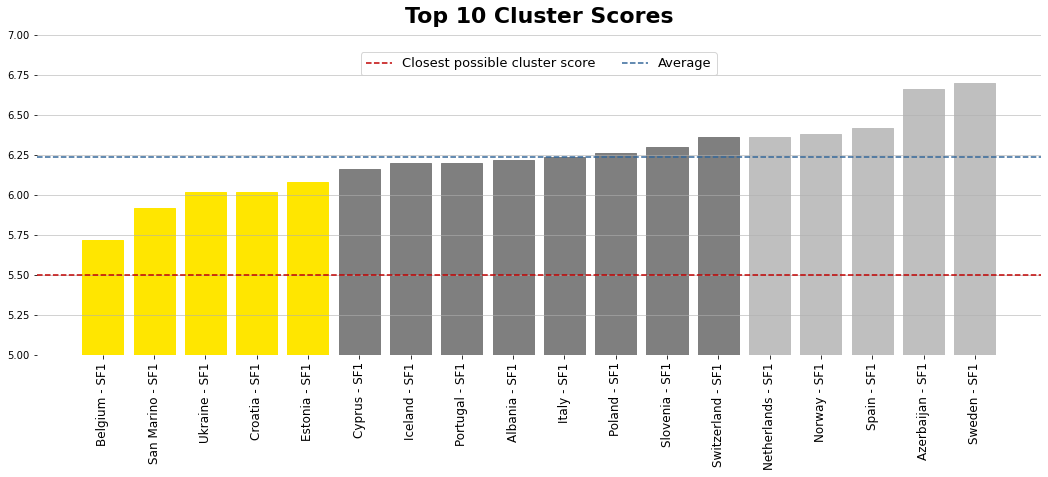

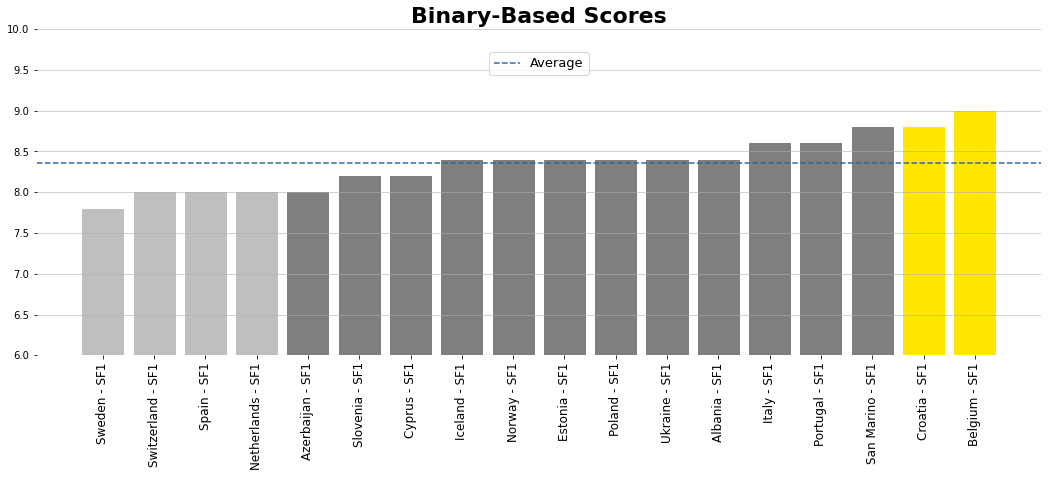

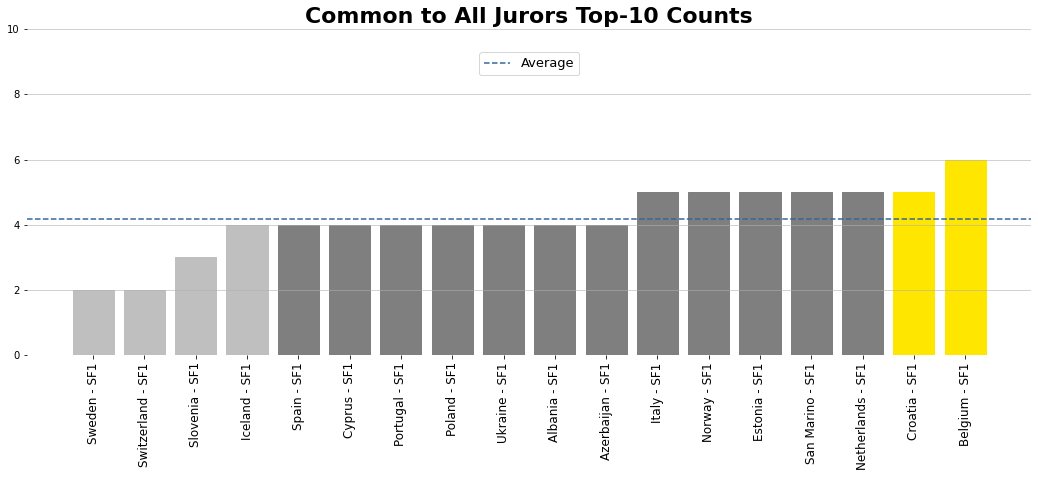

Correlation between Top-10 Cluster and Binary scores: -0.8647532287257576
Correlation between Top-10 Cluster and Kendall's W scores: -0.8500304294810213
Correlation between Binary and Kendall's W scores: 0.6763939216226595
Correlation between Common to all Jurors Top-10 and Top-10 Cluster scores: -0.6310194128205195


In [18]:
#################
### FULL LOOP ###
#################

for country in tqdm(selected_df['ownICO_FULL'].unique()):
    
    # Select the partial dataframe containing all juries from a selected countries 
    selected_country = country
    selected_country_df = selected_df[(selected_df['ownICO_FULL'] == selected_country) & (selected_df['votedICO_FULL'] != selected_country)]
    selected_country_df = selected_country_df[['ownICO_FULL', 'function', 'votedICO_FULL', 'rank']].sort_values(['function', 'rank'])
    
    # Convert ranks to exponential scores    
    selected_country_df['exp_score'] = selected_country_df['rank'].apply(rank_to_exp_score)
    
    # Group by 'votedICO_FULL' and sum the 'exp_score' column
    grouped_points = selected_country_df.groupby('votedICO_FULL')['exp_score'].sum()

    # Sort by descending order of points and reset the index
    sorted_points = grouped_points.sort_values(ascending=False).reset_index()

    # Calculate the threshold for the top 10 values in the 'exp_score' column
    top_10_threshold = sorted_points['exp_score'].nlargest(10).min()

    sorted_points = sorted_points.rename(columns={'exp_score': 'total_exp_score'})

    sorted_points['total_rank'] = sorted_points['total_exp_score'].rank(method='first', ascending=False).astype(int)

    # Add a new column 'InTop10', where value is True if the row has one of the top 10 values in column 'exp_score'
    sorted_points['InTop10'] = sorted_points['total_exp_score'].apply(lambda x: True if x >= top_10_threshold else False)

    selected_country_enriched_df = selected_country_df.merge(sorted_points[['votedICO_FULL', 'InTop10', 'total_rank','total_exp_score']], on='votedICO_FULL', suffixes=('', '_sorted'))

    selected_country_enriched_df = selected_country_enriched_df.sort_values(['total_exp_score','total_rank','function'],ascending=[False, True, True]).reset_index()

    selected_country_enriched_df = selected_country_enriched_df.drop(columns=['index'])

    # Calculate the average of the 'rank' values where the 'InTop10' column is True
    average_rank = selected_country_enriched_df[selected_country_enriched_df['InTop10']]['rank'].mean()
    
    top10_cluster_scores_dict[selected_country] = round(average_rank,3)
    
    # Same thing for binary value (10 = in top 10, 0 = not in top ten)
    selected_country_enriched_df['InJurorTop10_INT'] = selected_country_enriched_df['rank'].apply(lambda x: 10 if x < 11 else 0) 

    binary_average_rank = selected_country_enriched_df[selected_country_enriched_df['InTop10']]['InJurorTop10_INT'].mean()
    
    #print(selected_country_enriched_df[selected_country_enriched_df['InTop10']]['InJurorTop10_INT'])
    
    binary_top10_dict[selected_country] = round(binary_average_rank,3)

    selected_country_enriched_df.to_excel(f'./Graph_Export/{round(average_rank,3)}_{selected_country}_juror_rankings_score.xlsx', index=False)

    # Kendall approach (order will matter, use it as a correlation QC)
    # Group the DataFrame by 'votedICO_FULL' and select the 'rank' column
    grouped_data = selected_country_enriched_df.groupby('votedICO_FULL')['rank']

    # Initialize an empty list to store the sub-lists
    list_of_lists = []

    # Iterate through the grouped data and append the 'rank' values as sub-lists
    for _, group in grouped_data:
        list_of_lists.append(group.values.tolist())

    W = kw.compute_w(list_of_lists)
    #print(f"Kendall's W coefficient for {selected_country}: {W}")

    kendall_w_dict[selected_country] = round(W,3)
    
    # Identifying top-10 countries common to all jurors
    # Check how many jurors in the current voting country
    jurors_in_country = len(selected_df['function'].unique())

    # Identify top-10 countries which are in jurors individuals top-10
    top_10_countries_df = selected_country_enriched_df[(selected_country_enriched_df['InTop10'] == True) & (selected_country_enriched_df['rank'] <= 10)]

    nb_of_top10_countries_in_each_jurors_top10 = 0

    for i in top_10_countries_df['votedICO_FULL'].unique():
        if top_10_countries_df[top_10_countries_df['votedICO_FULL'] == i].shape[0] == jurors_in_country:
            nb_of_top10_countries_in_each_jurors_top10 += 1
            print(f'Country "{i}" is found in all {jurors_in_country} jurors of {selected_country}')

    common_to_all_top10_dict[selected_country] = nb_of_top10_countries_in_each_jurors_top10   

    #print(f'\n{nb_of_top10_countries_in_each_jurors_top10} countries are found in all all {jurors_in_country} jurors of {selected_country}')

    
    
print(f'Top 10 Cluster Scores: {top10_cluster_scores_dict}\n')
print(f'Binary Scores: {binary_top10_dict}\n')
print(f'Kendall W Scores: {kendall_w_dict}\n')
print(f'Common to all Top 10 Counts: {common_to_all_top10_dict}\n')




#################################
### GRAPH TOP 10 CLUSTER PLOT ###
#################################
# Sort the dictionary by value in descending order
sorted_scores = sorted(top10_cluster_scores_dict.items(), key=lambda x: x[1], reverse=False)

# Unzip the keys and values
labels, values = zip(*sorted_scores)

# Create the bar chart
fig, ax = plt.subplots(figsize=(18, 6))
fig.set_facecolor('white')
ax.set_facecolor('white')
bars = ax.bar(labels, values)

# Set colors for the different groups of bars
num_lowest = 5
num_highest = 5

# Customize the chart
plt.title('Top 10 Cluster Scores', fontdict={'size': 22, 'weight': 700})
plt.xlabel('', fontsize=10)
plt.ylabel('', fontsize=10)
plt.xticks(rotation=90, fontsize=12)
ax.grid(axis='y', alpha=0.7)
ax.set_ylim(bottom=5)


# Remove the black border surrounding the graph
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Annotate the bars with their values
for i, bar in enumerate(bars):
    height = bar.get_height()
    '''
    ax.annotate(
        f'{height}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10
    )
    '''
    if i < num_lowest:
        bar.set_color('#FFE600')
    elif i >= len(bars) - num_highest:
        bar.set_color('#BFBFBF')
    else:
        bar.set_color('#7F7F7F')

# Add a horizontal red dashed line at 5.5
line = ax.axhline(5.5, color='#C00000', linestyle='--', label='Closest possible cluster score')

# Calculate the average value
average_value = sum(values) / len(values)

# Add a dark-blue dashed horizontal line at the average value
avg_line = ax.axhline(average_value, color='#336699', linestyle='--', label='Average')


# Add the legend
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2, fontsize=13)
     

# Show the chart
plt.savefig(os.path.join(
    GRAPH_OUTPUT_DIRECTORY, "Top10_chart.png"
), dpi=300, bbox_inches='tight')

plt.show()

################################
### GRAPH BINARY TOP 10 PLOT ###
################################
# Sort the dictionary by value in descending order
sorted_binary_scores = sorted(binary_top10_dict.items(), key=lambda x: x[1], reverse=False)

# Unzip the keys and values
labels, values = zip(*sorted_binary_scores)

# Create the bar chart
fig, ax = plt.subplots(figsize=(18, 6))
fig.set_facecolor('white')
ax.set_facecolor('white')
bars = ax.bar(labels, values)

# Set colors for the different groups of bars
num_lowest = 4
num_highest = 2

# Customize the chart
plt.title('Binary-Based Scores', fontdict={'size': 22, 'weight': 700})
plt.xlabel('', fontsize=10)
plt.ylabel('', fontsize=10)
plt.xticks(rotation=90, fontsize=12)
ax.grid(axis='y', alpha=0.7)
ax.set_ylim(top=10,bottom=6)


# Remove the black border surrounding the graph
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Annotate the bars with their values
for i, bar in enumerate(bars):
    height = bar.get_height()
    '''
    ax.annotate(
        f'{height}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10
    )
    '''
    if i < num_lowest:
        bar.set_color('#BFBFBF')
    elif i >= len(bars) - num_highest:
        bar.set_color('#FFE600')
    else:
        bar.set_color('#7F7F7F')

# Add a horizontal red dashed line at 5.5
# NOT USED FOR BINARY SCORING
# line = ax.axhline(5.5, color='#C00000', linestyle='--', label='Closest possible cluster score')

# Calculate the average value
average_value = sum(values) / len(values)

# Add a dark-blue dashed horizontal line at the average value
avg_line = ax.axhline(average_value, color='#336699', linestyle='--', label='Average')

# Add the legend
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2, fontsize=13)

# Show the chart
plt.savefig(os.path.join(
    GRAPH_OUTPUT_DIRECTORY, "Binary_chart.png"
), dpi=300, bbox_inches='tight')

#plt.show()

#################################
### COMMON TO ALL TOP 10 PLOT ###
#################################
# Sort the dictionary by value in descending order
sorted_common_to_all_top10_counts = sorted(common_to_all_top10_dict.items(), key=lambda x: x[1], reverse=False)

# Unzip the keys and values
labels, values = zip(*sorted_common_to_all_top10_counts)

# Create the bar chart
fig, ax = plt.subplots(figsize=(18, 6))
fig.set_facecolor('white')
ax.set_facecolor('white')
bars = ax.bar(labels, values)

# Set colors for the different groups of bars
num_lowest = 4
num_highest = 2

# Customize the chart
plt.title('Common to All Jurors Top-10 Counts', fontdict={'size': 22, 'weight': 700})
plt.xlabel('', fontsize=10)
plt.ylabel('', fontsize=10)
plt.xticks(rotation=90, fontsize=12)
ax.grid(axis='y', alpha=0.7)
ax.set_ylim(top=10,bottom=0)


# Remove the black border surrounding the graph
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Annotate the bars with their values
for i, bar in enumerate(bars):
    height = bar.get_height()
    '''
    ax.annotate(
        f'{height}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10
    )
    '''
    if i < num_lowest:
        bar.set_color('#BFBFBF')
    elif i >= len(bars) - num_highest:
        bar.set_color('#FFE600')
    else:
        bar.set_color('#7F7F7F')

# Add a horizontal red dashed line at 5.5

# Calculate the average value
average_value = sum(values) / len(values)

# Add a dark-blue dashed horizontal line at the average value
avg_line = ax.axhline(average_value, color='#336699', linestyle='--', label='Average')

# Add the legend
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2, fontsize=13)

# Show the chart
plt.savefig(os.path.join(
    GRAPH_OUTPUT_DIRECTORY, "Common_to_all_Top10_chart.png"
), dpi=300, bbox_inches='tight')

plt.show()


###########################
### CORRELATION SCORING ###
###########################
# Calculate the correlation score between the top10 scores and the Kendall's W scores
top10_scores = [top10_cluster_scores_dict[key] for key in top10_cluster_scores_dict]

kendall_w = [kendall_w_dict[key] for key in kendall_w_dict]

binary_scores = [binary_top10_dict[key] for key in binary_top10_dict]

common_top10_scores = [common_to_all_top10_dict[key] for key in common_to_all_top10_dict]

correlation_top10_bin, _ = scipy.stats.pearsonr(top10_scores, binary_scores)
correlation_top10_kendal, _ = scipy.stats.pearsonr(top10_scores, kendall_w)
correlation_bin_kendal, _ = scipy.stats.pearsonr(binary_scores, kendall_w)
correlation_common_top10, _ = scipy.stats.pearsonr(common_top10_scores, top10_scores)

print("Correlation between Top-10 Cluster and Binary scores:", correlation_top10_bin)
print("Correlation between Top-10 Cluster and Kendall's W scores:", correlation_top10_kendal)
print("Correlation between Binary and Kendall's W scores:", correlation_bin_kendal)
print("Correlation between Common to all Jurors Top-10 and Top-10 Cluster scores:", correlation_common_top10)

The primary test performed was the Top-10 Cluster Score which identifies whether each 
member within a National Jury voted for the same countries in the top ten places (i.e., 
qualifying for the GF), albeit not necessarily in the same order.  

For example, if all members of a National Jury voted for the same top ten (regardless of 
order), the score on the graph below would be 5.5 (i.e., adding places 1 to 10 and dividing 
by 10 for each juror and taking the average of all Jurors by country). The more variation in 
the top ten, the further away from (i.e., higher than) 5.5 the score will be. 

The closer the score is to 5.5, the closer the jurors are voting in the same manner for the 
top 10 (although not necessarily in the same order), either through pre-agreement or as a 
function of perfectly aligned musical appreciation (considered unlikely). 

The further the score is from 5.5, the wider the differences in the individual jurors’ voting. 
With both SF1 / SF2 having 17 / 18 contestants respectively, the theoretical maximum top 
10 score approaches 9.0 / 10.0 respectively which could also indicate pre-agreement on 
voting or a function of perfectly un-aligned musical appreciation (considered unlikely). 

# Top X Cluster Plots
- Define function that calculates the corrected dataframe
- Generate the top X cluster plot from 3 to 10 to evaluate if there are any additional red flags to be observed

In [23]:
def topXcluster_dict(n_cluster,selected_df,topX_cluster_scores_dict):
    
    for country in selected_df['ownICO_FULL'].unique():

        # Select the partial dataframe containing all juries from a selected countries 
        selected_country = country
        selected_country_df = selected_df[(selected_df['ownICO_FULL'] == selected_country) & (selected_df['votedICO_FULL'] != selected_country)]
        selected_country_df = selected_country_df[['ownICO_FULL', 'function', 'votedICO_FULL', 'rank']].sort_values(['function', 'rank'])

        # Convert ranks to exponential scores    
        selected_country_df['exp_score'] = selected_country_df['rank'].apply(rank_to_exp_score)
        
        # Group by 'votedICO_FULL' and sum the 'exp_score' column
        grouped_points = selected_country_df.groupby('votedICO_FULL')['exp_score'].sum()
        
        # Sort by descending order of points and reset the index
        sorted_points = grouped_points.sort_values(ascending=False).reset_index()

        # Calculate the threshold for the top 10 values in the 'exp_score' column
        top_X_threshold = sorted_points['exp_score'].nlargest(n_cluster).min()
    
        sorted_points = sorted_points.rename(columns={'exp_score': 'total_exp_score'})
        sorted_points['total_rank'] = sorted_points['total_exp_score'].rank(method='first', ascending=False).astype(int)

        # Add a new column 'InTop10', where value is True if the row has one of the top 10 values in column 'exp_score'
        sorted_points['InTopX'] = sorted_points['total_exp_score'].apply(lambda x: True if x >= top_X_threshold else False)

        selected_country_enriched_df = selected_country_df.merge(sorted_points[['votedICO_FULL', 'InTopX', 'total_rank','total_exp_score']], on='votedICO_FULL', suffixes=('', '_sorted'))

        selected_country_enriched_df = selected_country_enriched_df.sort_values(['total_exp_score','total_rank','function'],ascending=[False, True, True]).reset_index()

        selected_country_enriched_df = selected_country_enriched_df.drop(columns=['index'])

        # Calculate the average of the 'rank' values where the 'InTop10' column is True
        average_rank = selected_country_enriched_df[selected_country_enriched_df['InTopX']]['rank'].mean()

        topX_cluster_scores_dict[selected_country] = round(average_rank,3)
        
    #return pd.DataFrame(topX_cluster_scores_dict,columns=['Country','ClusterScore'])
    #print(topX_cluster_scores_dict)
    #print('should be done now')
    
    return topX_cluster_scores_dict

FileNotFoundError: [Errno 2] No such file or directory: 'Graph_Export\\Top3_chart.png'

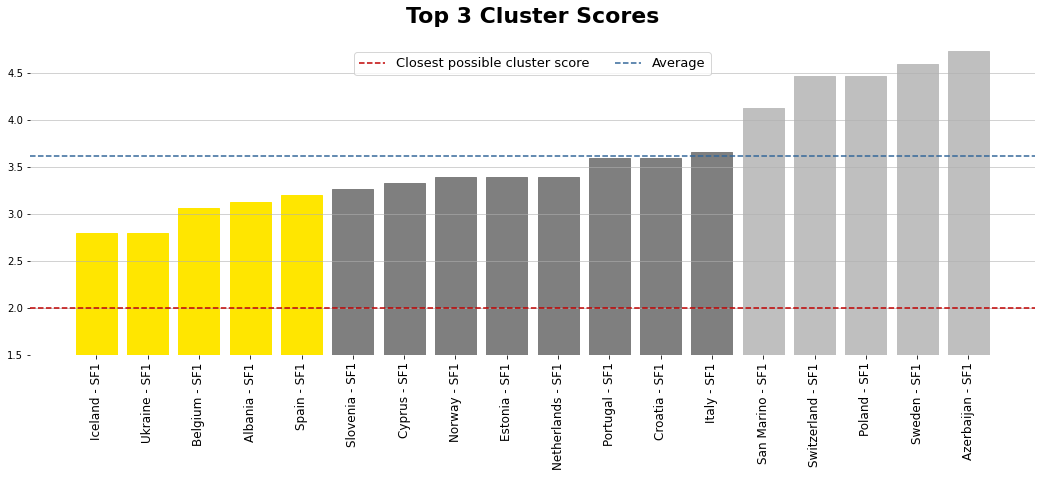

In [24]:
#################################
### GRAPH TOP X CLUSTER PLOT ###
#################################
# Sort the dictionary by value in descending order

# Add traces, one for each slider step
for step in np.arange(3, 11, 1):
    
    df = topXcluster_dict(step,selected_df,{})
    sorted_scores = sorted(df.items(), key=lambda x: x[1], reverse=False)

    # Unzip the keys and values
    labels, values = zip(*sorted_scores)

    # Create the bar chart
    fig, ax = plt.subplots(figsize=(18, 6))
    fig.set_facecolor('white')
    ax.set_facecolor('white')
    bars = ax.bar(labels, values)

    # Set colors for the different groups of bars
    num_lowest = 5
    num_highest = 5

    # Customize the chart
    plt.title(f'Top {step} Cluster Scores', fontdict={'size': 22, 'weight': 700})
    plt.xlabel('', fontsize=10)
    plt.ylabel('', fontsize=10)
    plt.xticks(rotation=90, fontsize=12)
    ax.grid(axis='y', alpha=0.7)
    ax.set_ylim(bottom=5)


    # Remove the black border surrounding the graph
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Annotate the bars with their values
    for i, bar in enumerate(bars):
        height = bar.get_height()
        '''
        ax.annotate(
            f'{height}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=10
        )
        '''
        if i < num_lowest:
            bar.set_color('#FFE600')
        elif i >= len(bars) - num_highest:
            bar.set_color('#BFBFBF')
        else:
            bar.set_color('#7F7F7F')

    # Add a horizontal red dashed line at 5.5
    
    closest_cluster_line = sum(range(1,step+1,1))/step
    ax.set_ylim(bottom=closest_cluster_line-0.5)
    
    
    line = ax.axhline(closest_cluster_line, color='#C00000', linestyle='--', label='Closest possible cluster score')

    # Calculate the average value
    average_value = sum(values) / len(values)

    # Add a dark-blue dashed horizontal line at the average value
    avg_line = ax.axhline(average_value, color='#336699', linestyle='--', label='Average')


    # Add the legend
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2, fontsize=13)


    # Show the chart
    plt.savefig(os.path.join(
        GRAPH_OUTPUT_DIRECTORY, f"Top{step}_chart.png"
    ), dpi=300, bbox_inches='tight')

    plt.show()
